In [1]:
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
import jax, flax; print('jax', jax.__version__); print('flax', flax.__version__)

jax 0.10.0
flax 0.12.7


In [3]:
jax.devices()

[CudaDevice(id=0)]

In [4]:
import astro_emulators_toolkit as aemu

In [5]:
em = aemu.Emulator.from_pretrained('RozanskiT/TPayne-spice-harps')

Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

In [6]:
from spice.spectrum.aemu_spectrum_emulator import IntensityPretrainedAemuSpectrumEmulator

em = IntensityPretrainedAemuSpectrumEmulator('RozanskiT/TPayne-spice-harps')

Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

In [7]:
import numpy as np
wave = np.linspace(5000, 5070, 1000)

f = em.intensity(np.log10(wave), 0.5, em.solar_parameters)

/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/spice/spectrum/aemu_spectrum_emulator.py:57: UserWarning: Possible exceeding parameter bonds - extrapolating.
  warnings.warn("Possible exceeding parameter bonds - extrapolating.")


In [8]:
import matplotlib.pyplot as plt

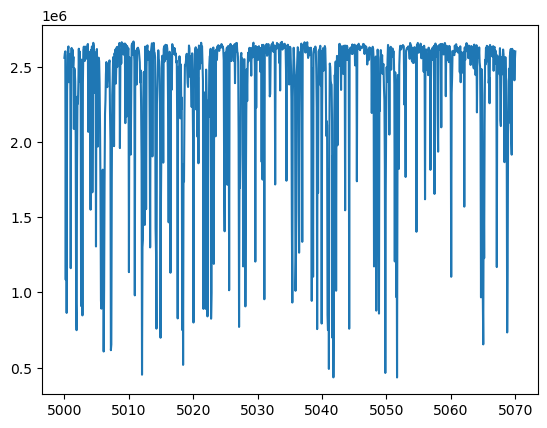

In [10]:
plt.plot(wave, f[:, 0]);

In [13]:
from spice.models import IcosphereModel
from spice.spectrum import simulate_observed_flux

N_VERTICES = 20000
RADIUS = 1.0      # solar radii
MASS = 1.0        # solar masses
DISTANCE = 10.0   # parsecs

mesh = IcosphereModel.construct(
    N_VERTICES, RADIUS, MASS,
    em.to_parameters(),
    em.stellar_parameter_names,
    override_log_g=False,   # the dummy parameter slot is not a log g axis
)


/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/spice/spectrum/aemu_spectrum_emulator.py:57: UserWarning: Possible exceeding parameter bonds - extrapolating.
  warnings.warn("Possible exceeding parameter bonds - extrapolating.")


[spice] IcosphereModel constructed in 4.5 s


In [14]:
import jax.numpy as jnp
sim_wavelengths = np.linspace(5000, 5070, 1000)
o = simulate_observed_flux(em.intensity, mesh, jnp.log10(sim_wavelengths), distance=DISTANCE, disable_doppler_shift=True)

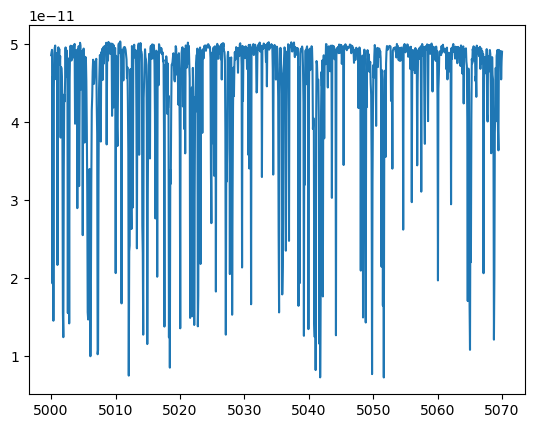

In [15]:
plt.plot(sim_wavelengths, o[:, 0])